# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [54]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [55]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [56]:
# Q1: Current UTC and IIT Kanpur time

from astropy.time import Time
from zoneinfo import ZoneInfo

now = Time.now()

print("Current UTC:", now.utc.isot)
print("IIT Kanpur time:", now.to_datetime(timezone=ZoneInfo("Asia/Kolkata")).strftime("%Y-%m-%d %H:%M:%S IST"))



Current UTC: 2026-09-03T18:45:59.707
IIT Kanpur time: 2026-09-04 00:15:59 IST


Two separate calls to `Time.now()` need not describe exactly the same instant because a small amount of time passes between the two calls.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [57]:
# Q2: Physical quantities and unit conversions
from astropy import units as u

height = 2396 * u.m
wavelength = 600 * u.nm
uncertainty = 5 * u.mas
cadence = 10 * u.min
frequency = 1.4 * u.GHz

# Conversions
height_km = height.to(u.km)

wavelength_frequency = wavelength.to(
    u.THz,
    equivalencies=u.spectral()
)

uncertainty_arcsec = uncertainty.to(u.arcsec)

cadence_hours = cadence.to(u.hour)

frequency_wavelength = frequency.to(
    u.cm,
    equivalencies=u.spectral()
)

# Print original and converted values
print("GTC height:", height, "->", height_km)
print("Wavelength:", wavelength, "->", wavelength_frequency)
print("Coordinate uncertainty:", uncertainty, "->", uncertainty_arcsec)
print("Cadence:", cadence, "->", cadence_hours)
print("Radio frequency:", frequency, "->", frequency_wavelength)

GTC height: 2396.0 m -> 2.396 km
Wavelength: 600.0 nm -> 499.6540966666666 THz
Coordinate uncertainty: 5.0 mas -> 0.005 arcsec
Cadence: 10.0 min -> 0.16666666666666666 h
Radio frequency: 1.4 GHz -> 21.413747 cm


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [58]:
# Q3: UTC, JD, MJD, IST, and time arithmetic

from astropy.time import Time
from astropy import units as u
from zoneinfo import ZoneInfo

# Fixed course value
START_UTC = "2026-08-30T12:00:00"

# IIT Kanpur timezone
IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

# Construct planning_start
planning_start = Time(START_UTC, scale="utc")

# Convert to IIT Kanpur time
planning_start_ist = planning_start.to_datetime(
    timezone=IITK_TIMEZONE
)

# Print original time information
print("UTC:", planning_start.utc.isot)
print("Julian Date (JD):", planning_start.jd)
print("Modified Julian Date (MJD):", planning_start.mjd)
print(
    "IIT Kanpur time:",
    planning_start_ist.strftime("%Y-%m-%d %H:%M:%S IST")
)

# Add 2.25 hours
later = planning_start + 2.25 * u.hour

print("\n2.25 hours later:")
print("UTC:", later.utc.isot)
print(
    "IIT Kanpur time:",
    later.to_datetime(
        timezone=IITK_TIMEZONE
    ).strftime("%Y-%m-%d %H:%M:%S IST")
)

# Convert the original IST-aware Python datetime back into Time
roundtrip_time = Time(planning_start_ist)

# Calculate difference in microseconds
difference_us = abs(
    (roundtrip_time - planning_start).to_value(u.s)
) * 1e6

print("\nRound-trip difference:", difference_us, "microseconds")
print("Less than 1 microsecond:", difference_us < 1)

UTC: 2026-08-30T12:00:00.000
Julian Date (JD): 2461283.0
Modified Julian Date (MJD): 61282.5
IIT Kanpur time: 2026-08-30 17:30:00 IST

2.25 hours later:
UTC: 2026-08-30T14:15:00.000
IIT Kanpur time: 2026-08-30 19:45:00 IST

Round-trip difference: 0.0 microseconds
Less than 1 microsecond: True


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [59]:
# Q4: Parse angles and construct an ICRS coordinate

from astropy.coordinates import Angle, SkyCoord
from astropy import units as u

# Fixed FRB 20220912A coordinates
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"

# Parse RA and Dec
ra = Angle(FRB_RA_J2000)
dec = Angle(FRB_DEC_J2000)

# Construct ICRS coordinate
frb_icrs = SkyCoord(
    ra=ra,
    dec=dec,
    frame="icrs"
)

# Print decimal degrees
print("RA in decimal degrees:", frb_icrs.ra.deg)
print("Dec in decimal degrees:", frb_icrs.dec.deg)

# Print padded sexagesimal notation
print("RA in sexagesimal:", frb_icrs.ra.to_string(
    unit=u.hourangle,
    sep=":",
    pad=True,
    precision=4
))

print("Dec in sexagesimal:", frb_icrs.dec.to_string(
    unit=u.deg,
    sep=":",
    pad=True,
    alwayssign=True,
    precision=4
))

# Verify expected values
expected_ra = 347.2704120833
expected_dec = 48.7066410556

ra_error = abs(frb_icrs.ra.deg - expected_ra)
dec_error = abs(frb_icrs.dec.deg - expected_dec)

print("\nRA error:", ra_error, "degree")
print("Dec error:", dec_error, "degree")

print("RA verification:", ra_error < 1e-8)
print("Dec verification:", dec_error < 1e-8)

RA in decimal degrees: 347.27041208333327
Dec in decimal degrees: 48.70664105555556
RA in sexagesimal: 23:09:04.8989
Dec in sexagesimal: +48:42:23.9078

RA error: 3.325340003357269e-11 degree
Dec error: 4.4444448121794267e-11 degree
RA verification: True
Dec verification: True


RA commonly uses hours because the sky appears to rotate through 24 hours of right ascension during one rotation of Earth. Declination uses degrees because it measures angular position north or south of the celestial equator.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [60]:
# Q5: ICRS to Galactic and back

from astropy.coordinates import SkyCoord
from astropy import units as u

# Construct the FRB ICRS coordinate
frb_icrs = SkyCoord(
    ra="23h09m04.8989s",
    dec="+48d42m23.9078s",
    frame="icrs"
)

# Transform ICRS to Galactic coordinates
frb_galactic = frb_icrs.galactic

# Print Galactic longitude and latitude
print("Galactic longitude (l):", frb_galactic.l.deg, "deg")
print("Galactic latitude (b):", frb_galactic.b.deg, "deg")

# Transform Galactic coordinates back to ICRS
frb_icrs_back = frb_galactic.icrs

# Calculate round-trip separation
roundtrip_separation = frb_icrs.separation(frb_icrs_back)

print("Round-trip separation:", roundtrip_separation.to(u.microarcsecond))

Galactic longitude (l): 106.06496077332801 deg
Galactic latitude (b): -10.784176285402491 deg
Round-trip separation: 0.000289774 uarcsec


The tiny non-zero round-trip separation represents numerical round-off and floating-point precision in the coordinate transformations. It does not indicate a physically meaningful change in the source position.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [61]:
# Q6: ICRS to Ecliptic and back

from astropy.coordinates import SkyCoord, BarycentricTrueEcliptic
from astropy import units as u

# Construct the FRB ICRS coordinate
frb_icrs = SkyCoord(
    ra="23h09m04.8989s",
    dec="+48d42m23.9078s",
    frame="icrs"
)

# Transform to Barycentric True Ecliptic coordinates at J2000
frb_ecliptic = frb_icrs.transform_to(
    BarycentricTrueEcliptic(equinox="J2000")
)

# Print ecliptic longitude and latitude
print("Ecliptic longitude (lambda):", frb_ecliptic.lon.deg, "deg")
print("Ecliptic latitude (beta):", frb_ecliptic.lat.deg, "deg")

# Verify valid ranges
lambda_valid = 0 <= frb_ecliptic.lon.deg < 360
beta_valid = -90 <= frb_ecliptic.lat.deg <= 90

print("\nLongitude valid range:", lambda_valid)
print("Latitude valid range:", beta_valid)

# Transform back to ICRS
frb_icrs_back = frb_ecliptic.transform_to("icrs")

# Calculate round-trip separation
roundtrip_separation = frb_icrs.separation(frb_icrs_back)

print(
    "Round-trip separation:",
    roundtrip_separation.to(u.microarcsecond)
)

Ecliptic longitude (lambda): 14.411187650340105 deg
Ecliptic latitude (beta): 48.34695843744783 deg

Longitude valid range: True
Latitude valid range: True
Round-trip separation: 0 uarcsec


The ecliptic plane is the plane of Earth's orbit around the Sun. Ecliptic longitude (λ) gives the position along this plane, while ecliptic latitude (β) gives the angular distance north or south of the ecliptic plane. Therefore, the value of β tells us how far the FRB is located above or below the Earth's orbital plane on the sky.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [62]:
# Q7: Angular separation

import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u

# Current FRB position
frb_icrs = SkyCoord(
    ra="23h09m04.8989s",
    dec="+48d42m23.9078s",
    frame="icrs"
)

# Earlier position
earlier_position = SkyCoord(
    ra="23h09m04.9s",
    dec="+48d42m25.4s",
    frame="icrs"
)

# Convert RA and Dec to radians
alpha1 = frb_icrs.ra.to_value(u.rad)
delta1 = frb_icrs.dec.to_value(u.rad)

alpha2 = earlier_position.ra.to_value(u.rad)
delta2 = earlier_position.dec.to_value(u.rad)

# Great-circle separation formula
cos_theta = (
    np.sin(delta1) * np.sin(delta2)
    + np.cos(delta1) * np.cos(delta2)
    * np.cos(alpha2 - alpha1)
)

# Protect against numerical round-off
cos_theta = np.clip(cos_theta, -1.0, 1.0)

# Separation in radians
theta = np.arccos(cos_theta)

# Convert to arcseconds and milliarcseconds
theta_arcsec = np.degrees(theta) * 3600
theta_mas = theta_arcsec * 1000

print("Manual angular separation:")
print("Separation:", theta_arcsec, "arcsec")
print("Separation:", theta_mas, "mas")

# Astropy separation
astropy_separation = frb_icrs.separation(earlier_position)

print("\nAstropy angular separation:")
print("Separation:", astropy_separation.to(u.arcsec))

# Compare the two results
astropy_arcsec = astropy_separation.to_value(u.arcsec)
difference = abs(theta_arcsec - astropy_arcsec)

print("\nDifference between manual and Astropy:", difference, "arcsec")
print("Agreement within 1e-6 arcsec:", difference < 1e-6)

Manual angular separation:
Separation: 1.4922406144066507 arcsec
Separation: 1492.2406144066506 mas

Astropy angular separation:
Separation: 1.49224 arcsec

Difference between manual and Astropy: 8.88226100892453e-07 arcsec
Agreement within 1e-6 arcsec: True


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [63]:
# Q8: Define the GTC observing site

from astropy.coordinates import EarthLocation
from astropy import units as u

# Fixed GTC coordinates
GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

# Construct GTC EarthLocation
gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m
)

# Print recovered geodetic values
print("GTC longitude:", gtc_location.lon)
print("GTC latitude:", gtc_location.lat)
print("GTC height:", gtc_location.height)

GTC longitude: -17d53m20.4s
GTC latitude: 28d45m28.8s
GTC height: 2395.9999999998504 m


The negative longitude means that the GTC is located west of the Greenwich meridian. Its longitude is approximately 17.889° west.

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [64]:
# Q9: Calculate GTC LST and hour angle at one instant

from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord
from astropy import units as u

# Fixed GTC location
gtc_location = EarthLocation.from_geodetic(
    lon=-17.889 * u.deg,
    lat=28.758 * u.deg,
    height=2396 * u.m
)

# Fixed FRB coordinate
frb_icrs = SkyCoord(
    ra="23h09m04.8989s",
    dec="+48d42m23.9078s",
    frame="icrs"
)

# Required instant
q9_time = Time(
    "2026-08-31T00:00:00",
    scale="utc"
)

# Calculate apparent Local Sidereal Time
lst = q9_time.sidereal_time(
    kind="apparent",
    longitude=gtc_location.lon
)

# Calculate hour angle H = LST - RA
hour_angle = (lst - frb_icrs.ra).wrap_at(12 * u.hourangle)

# Convert UTC to IIT Kanpur time
iitk_time = q9_time.to_datetime(
    timezone=__import__("zoneinfo").ZoneInfo("Asia/Kolkata")
)

# Print results
print("UTC:", q9_time.utc.isot)
print(
    "IIT Kanpur time:",
    iitk_time.strftime("%Y-%m-%d %H:%M:%S IST")
)
print("LST:", lst.to_string(unit=u.hourangle, sep=":", pad=True))
print(
    "Hour angle:",
    hour_angle.to_string(unit=u.hourangle, sep=":", pad=True)
)

# Determine position relative to meridian
if hour_angle > 0 * u.hourangle:
    print("Position: West of the meridian")
elif hour_angle < 0 * u.hourangle:
    print("Position: East of the meridian")
else:
    print("Position: Transiting")

UTC: 2026-08-31T00:00:00.000
IIT Kanpur time: 2026-08-31 05:30:00 IST
LST: 21:25:12.20694727
Hour angle: -01:43:52.69195273
Position: East of the meridian


The hour angle is defined as H = LST − α. A negative hour angle means the target is east of the meridian, a positive hour angle means it is west of the meridian, and H = 0 corresponds to meridian transit.

## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [65]:
# Q10: Find the nearest sampled meridian transit

import numpy as np
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord
from astropy import units as u
from zoneinfo import ZoneInfo

# Fixed GTC location
gtc_location = EarthLocation.from_geodetic(
    lon=-17.889 * u.deg,
    lat=28.758 * u.deg,
    height=2396 * u.m
)

# Fixed FRB coordinate
frb_icrs = SkyCoord(
    ra="23h09m04.8989s",
    dec="+48d42m23.9078s",
    frame="icrs"
)

# Create the 145-sample UTC grid
start_time = Time("2026-08-30T12:00:00", scale="utc")
stop_time = Time("2026-08-31T12:00:00", scale="utc")

times = start_time + np.arange(145) * 10 * u.min

# Calculate apparent GTC LST for all samples
lst = times.sidereal_time(
    kind="apparent",
    longitude=gtc_location.lon
)

# Calculate wrapped hour angle
hour_angle = (
    lst - frb_icrs.ra
).wrap_at(12 * u.hourangle)

# Find the sample closest to transit
transit_index = np.argmin(
    np.abs(hour_angle.to_value(u.hourangle))
)

transit_time = times[transit_index]
transit_lst = lst[transit_index]
transit_hour_angle = hour_angle[transit_index]

# Convert transit time to IIT Kanpur time
iitk_timezone = ZoneInfo("Asia/Kolkata")
transit_ist = transit_time.to_datetime(
    timezone=iitk_timezone
)

# Print results
print("Nearest sampled meridian transit")
print("--------------------------------")
print("Sample index:", transit_index)
print("UTC:", transit_time.utc.isot)
print(
    "IIT Kanpur time:",
    transit_ist.strftime("%Y-%m-%d %H:%M:%S IST")
)
print(
    "LST:",
    transit_lst.to_string(
        unit=u.hourangle,
        sep=":",
        pad=True
    )
)
print(
    "Hour angle:",
    transit_hour_angle.to_string(
        unit=u.hourangle,
        sep=":",
        pad=True
    )
)

Nearest sampled meridian transit
--------------------------------
Sample index: 82
UTC: 2026-08-31T01:40:00.000
IIT Kanpur time: 2026-08-31 07:10:00 IST
LST: 23:05:28.63380294
Hour angle: -00:03:36.26509706


The result is a sampled approximation because the calculation checks the source position only every 10 minutes. The exact meridian transit can occur between two sampled times, so the sample with the smallest absolute hour angle is the nearest sampled transit rather than the exact transit instant.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [66]:
import numpy as np
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy import units as u
from zoneinfo import ZoneInfo

# GTC location
gtc_location = EarthLocation.from_geodetic(
    lon=-17.889 * u.deg,
    lat=28.758 * u.deg,
    height=2396 * u.m
)

# FRB coordinates
frb_icrs = SkyCoord(
    ra="23h09m04.8989s",
    dec="+48d42m23.9078s",
    frame="icrs"
)

# Observation time grid: 10-minute sampling
start_time = Time("2026-08-30T12:00:00", scale="utc")
times = start_time + np.arange(145) * 10 * u.min

# ---------------------------------------------------------
# Analytic altitude at upper meridian transit
# h_transit = 90° - |latitude - declination|
# ---------------------------------------------------------

latitude = gtc_location.lat.to_value(u.deg)
declination = frb_icrs.dec.to_value(u.deg)

h_transit = 90.0 - abs(latitude - declination)
z_transit = 90.0 - h_transit

print("Analytic upper-transit calculation")
print("----------------------------------")
print("GTC latitude:", latitude, "deg")
print("FRB declination:", declination, "deg")
print("Predicted transit altitude:", h_transit, "deg")
print("Predicted zenith distance:", z_transit, "deg")

# ---------------------------------------------------------
# Astropy AltAz transformation
# pressure=0 means vacuum / no atmospheric refraction
# ---------------------------------------------------------

altaz_frame = AltAz(
    obstime=times,
    location=gtc_location,
    pressure=0 * u.hPa
)

frb_altaz = frb_icrs.transform_to(altaz_frame)

altitudes = frb_altaz.alt.to_value(u.deg)
zenith_distances = 90.0 - altitudes

# Find the largest sampled altitude
max_index = np.argmax(altitudes)

max_altitude = altitudes[max_index]
max_zenith_distance = zenith_distances[max_index]
max_time = times[max_index]

print("\nAstropy sampled result")
print("----------------------")
print("Maximum sampled altitude:", max_altitude, "deg")
print("Corresponding zenith distance:", max_zenith_distance, "deg")
print("Sample index:", max_index)
print("UTC:", max_time.utc.isot)
print(
    "IIT Kanpur time:",
    max_time.to_datetime(
        timezone=ZoneInfo("Asia/Kolkata")
    ).strftime("%Y-%m-%d %H:%M:%S IST")
)

# ---------------------------------------------------------
# Comparison
# ---------------------------------------------------------

altitude_difference = abs(max_altitude - h_transit)
zenith_difference = abs(max_zenith_distance - z_transit)

print("\nComparison")
print("----------")
print("Altitude difference:", altitude_difference, "deg")
print("Zenith-distance difference:", zenith_difference, "deg")

Analytic upper-transit calculation
----------------------------------
GTC latitude: 28.758 deg
FRB declination: 48.70664105555556 deg
Predicted transit altitude: 70.05135894444444 deg
Predicted zenith distance: 19.948641055555555 deg

Astropy sampled result
----------------------
Maximum sampled altitude: 69.88391103909184 deg
Corresponding zenith distance: 20.116088960908158 deg
Sample index: 82
UTC: 2026-08-31T01:40:00.000
IIT Kanpur time: 2026-08-31 07:10:00 IST

Comparison
----------
Altitude difference: 0.1674479053526028 deg
Zenith-distance difference: 0.1674479053526028 deg


At upper meridian transit, the altitude is

$$
h_{\mathrm{transit}} = 90^\circ - |\phi - \delta|
$$

where $\phi$ is the observatory latitude and $\delta$ is the target declination.

The zenith distance is related to altitude by

$$
z = 90^\circ - h
$$

The analytic transit altitude should be close to the maximum altitude obtained from the Astropy `AltAz` transformation. A small difference is expected because the Astropy result is evaluated only at the 10-minute sampled times, so the exact meridian transit can occur between two samples.

## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [67]:
import numpy as np
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy import units as u
from zoneinfo import ZoneInfo

# GTC location
gtc_location = EarthLocation.from_geodetic(
    lon=-17.889 * u.deg,
    lat=28.758 * u.deg,
    height=2396 * u.m
)

# FRB coordinates
frb_icrs = SkyCoord(
    ra="23h09m04.8989s",
    dec="+48d42m23.9078s",
    frame="icrs"
)

# Observation time grid
start_time = Time("2026-08-30T12:00:00", scale="utc")
times = start_time + np.arange(145) * 10 * u.min

# Calculate apparent LST and wrapped hour angle
lst = times.sidereal_time(
    kind="apparent",
    longitude=gtc_location.lon
)

hour_angle = (
    lst - frb_icrs.ra
).wrap_at(12 * u.hourangle)

# Find nearest sampled transit
transit_index = np.argmin(
    np.abs(hour_angle.to_value(u.hourangle))
)

# Select the sample before, at, and after transit
indices = [transit_index - 1, transit_index, transit_index + 1]

# Latitude and declination in radians
phi = gtc_location.lat.to_value(u.rad)
delta = frb_icrs.dec.to_value(u.rad)

# Astropy AltAz transformation in vacuum
altaz_frame = AltAz(
    obstime=times,
    location=gtc_location,
    pressure=0 * u.hPa
)

frb_altaz = frb_icrs.transform_to(altaz_frame)

print("Altitude before, at, and after meridian transit")
print("------------------------------------------------")

for i in indices:
    H = hour_angle[i].to_value(u.rad)

    # Analytic altitude formula:
    # sin(h) = sin(phi)sin(delta) + cos(phi)cos(delta)cos(H)
    sin_h = (
        np.sin(phi) * np.sin(delta)
        + np.cos(phi) * np.cos(delta) * np.cos(H)
    )

    sin_h = np.clip(sin_h, -1.0, 1.0)

    analytic_altitude = np.degrees(np.arcsin(sin_h))
    astropy_altitude = frb_altaz.alt[i].to_value(u.deg)

    difference = abs(analytic_altitude - astropy_altitude)

    print("\nSample index:", i)
    print(
        "UTC:",
        times[i].utc.isot
    )
    print(
        "IIT Kanpur time:",
        times[i].to_datetime(
            timezone=ZoneInfo("Asia/Kolkata")
        ).strftime("%Y-%m-%d %H:%M:%S IST")
    )
    print(
        "Hour angle:",
        hour_angle[i].to_string(
            unit=u.hourangle,
            sep=":",
            pad=True
        )
    )
    print("Analytic altitude:", analytic_altitude, "deg")
    print("Astropy altitude:", astropy_altitude, "deg")
    print("Difference:", difference, "deg")

Altitude before, at, and after meridian transit
------------------------------------------------

Sample index: 81
UTC: 2026-08-31T01:30:00.000
IIT Kanpur time: 2026-08-31 07:00:00 IST
Hour angle: -00:13:37.90778299
Analytic altitude: 69.88025450174219 deg
Astropy altitude: 69.70374644589799 deg
Difference: 0.17650805584419516 deg

Sample index: 82
UTC: 2026-08-31T01:40:00.000
IIT Kanpur time: 2026-08-31 07:10:00 IST
Hour angle: -00:03:36.26509706
Analytic altitude: 70.03934732667062 deg
Astropy altitude: 69.88391103909184 deg
Difference: 0.15543628757878025 deg

Sample index: 83
UTC: 2026-08-31T01:50:00.000
IIT Kanpur time: 2026-08-31 07:20:00 IST
Hour angle: 00:06:25.37758896
Analytic altitude: 70.01324273682583 deg
Astropy altitude: 69.88095852533318 deg
Difference: 0.1322842114926459 deg


The altitude is calculated analytically using

$$
\sin h =
\sin\phi\sin\delta
+
\cos\phi\cos\delta\cos H
$$

where \(h\) is the altitude, \(\phi\) is the GTC latitude, \(\delta\) is the target declination, and \(H\) is the hour angle.

The analytical altitude is calculated for the sample immediately before transit, the nearest sampled transit, and the sample immediately after transit. These values are compared with the altitude obtained from the Astropy `AltAz` transformation.

The two methods should give very similar results. Small differences can occur because the observation times are sampled every 10 minutes and because Astropy performs the coordinate transformation numerically.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [68]:
import numpy as np
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord
from astropy import units as u

# GTC location
gtc_location = EarthLocation.from_geodetic(
    lon=-17.889 * u.deg,
    lat=28.758 * u.deg,
    height=2396 * u.m
)

# FRB coordinates
frb_icrs = SkyCoord(
    ra="23h09m04.8989s",
    dec="+48d42m23.9078s",
    frame="icrs"
)

# Observation time grid
start_time = Time("2026-08-30T12:00:00", scale="utc")
times = start_time + np.arange(145) * 10 * u.min

# Apparent LST and hour angle
lst = times.sidereal_time(
    kind="apparent",
    longitude=gtc_location.lon
)

hour_angle = (
    lst - frb_icrs.ra
).wrap_at(12 * u.hourangle)

# ---------------------------------------------------------
# Solve for limiting hour angle at minimum altitude = 20 deg
# ---------------------------------------------------------

phi = gtc_location.lat.to_value(u.rad)
delta = frb_icrs.dec.to_value(u.rad)
h_min = np.deg2rad(20.0)

# From:
# sin(h) = sin(phi)sin(delta) + cos(phi)cos(delta)cos(H)

cos_H_limit = (
    np.sin(h_min) - np.sin(phi) * np.sin(delta)
) / (
    np.cos(phi) * np.cos(delta)
)

cos_H_limit = np.clip(cos_H_limit, -1.0, 1.0)

H_limit = np.arccos(cos_H_limit)

H_limit_hours = np.degrees(H_limit) / 15.0

print("Limiting hour angle for altitude = 20 deg")
print("------------------------------------------")
print("Minimum altitude:", 20.0, "deg")
print("cos(H_limit):", cos_H_limit)
print("Positive limiting hour angle:", H_limit_hours, "hours")
print("Negative limiting hour angle:", -H_limit_hours, "hours")

# ---------------------------------------------------------
# Compare with sampled grid
# ---------------------------------------------------------

H_hours = hour_angle.to_value(u.hourangle)

# Samples satisfying altitude >= 20 deg
observable_samples = np.abs(H_hours) <= H_limit_hours

print("\nSampled grid comparison")
print("------------------------")
print("Number of samples with altitude >= 20 deg:",
      np.sum(observable_samples))

if np.any(observable_samples):
    first_index = np.where(observable_samples)[0][0]
    last_index = np.where(observable_samples)[0][-1]

    print("First qualifying sample index:", first_index)
    print("First qualifying hour angle:",
          H_hours[first_index], "hours")
    print("First qualifying UTC:",
          times[first_index].utc.isot)

    print("\nLast qualifying sample index:", last_index)
    print("Last qualifying hour angle:",
          H_hours[last_index], "hours")
    print("Last qualifying UTC:",
          times[last_index].utc.isot)

# Find sampled points closest to the two limiting hour angles
positive_boundary_index = np.argmin(
    np.abs(H_hours - H_limit_hours)
)

negative_boundary_index = np.argmin(
    np.abs(H_hours + H_limit_hours)
)

print("\nClosest sampled points to the altitude limit")
print("---------------------------------------------")

print("Positive boundary:")
print("Sample index:", positive_boundary_index)
print("Hour angle:", H_hours[positive_boundary_index], "hours")
print("UTC:", times[positive_boundary_index].utc.isot)

print("\nNegative boundary:")
print("Sample index:", negative_boundary_index)
print("Hour angle:", H_hours[negative_boundary_index], "hours")
print("UTC:", times[negative_boundary_index].utc.isot)

Limiting hour angle for altitude = 20 deg
------------------------------------------
Minimum altitude: 20.0 deg
cos(H_limit): -0.03363447508056853
Positive limiting hour angle: 6.128498466900158 hours
Negative limiting hour angle: -6.128498466900158 hours

Sampled grid comparison
------------------------
Number of samples with altitude >= 20 deg: 74
First qualifying sample index: 46
First qualifying hour angle: -6.076500482300176 hours
First qualifying UTC: 2026-08-30T19:40:00.000

Last qualifying sample index: 119
Last qualifying hour angle: 6.123476206867441 hours
Last qualifying UTC: 2026-08-31T07:50:00.000

Closest sampled points to the altitude limit
---------------------------------------------
Positive boundary:
Sample index: 119
Hour angle: 6.123476206867441 hours
UTC: 2026-08-31T07:50:00.000

Negative boundary:
Sample index: 46
Hour angle: -6.076500482300176 hours
UTC: 2026-08-30T19:40:00.000


The limiting hour angle is found by setting the altitude equal to the minimum allowed altitude of \(20^\circ\).

The altitude equation is

$$
\sin h =
\sin\phi\sin\delta
+
\cos\phi\cos\delta\cos H
$$

For \(h = 20^\circ\),

$$
\cos H_{\mathrm{limit}}
=
\frac{
\sin(20^\circ)-\sin\phi\sin\delta
}{
\cos\phi\cos\delta
}
$$

Therefore,

$$
H_{\mathrm{limit}}
=
\cos^{-1}
\left(
\frac{
\sin(20^\circ)-\sin\phi\sin\delta
}{
\cos\phi\cos\delta
}
\right)
$$

The target satisfies the altitude requirement when

$$
|H| \leq H_{\mathrm{limit}}.
$$

The calculated limiting hour angle is compared with the 10-minute sampled hour angles to identify the first and last qualifying samples. Because the time grid is sampled every 10 minutes, the exact altitude-limit crossing can occur between two sampled points.

# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [69]:
import numpy as np
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy import units as u
from zoneinfo import ZoneInfo

# GTC location
gtc_location = EarthLocation.from_geodetic(
    lon=-17.889 * u.deg,
    lat=28.758 * u.deg,
    height=2396 * u.m
)

# FRB coordinates
frb_icrs = SkyCoord(
    ra="23h09m04.8989s",
    dec="+48d42m23.9078s",
    frame="icrs"
)

# 145-sample UTC grid
start_time = Time("2026-08-30T12:00:00", scale="utc")
times = start_time + np.arange(145) * 10 * u.min

# Transform target to vacuum AltAz
altaz_frame = AltAz(
    obstime=times,
    location=gtc_location,
    pressure=0 * u.hPa
)

frb_gtc_altaz = frb_icrs.transform_to(altaz_frame)

# Convert sec(z) to a float array
target_airmass = np.asarray(
    frb_gtc_altaz.secz.to_value(u.dimensionless_unscaled),
    dtype=float
)

# Target altitude
target_altitude = frb_gtc_altaz.alt.to_value(u.deg)

# Replace invalid values:
# 1. Target at or below horizon
# 2. Non-finite airmass
# 3. Airmass below 1
invalid = (
    (target_altitude <= 0)
    | (~np.isfinite(target_airmass))
    | (target_airmass < 1)
)

target_airmass[invalid] = np.nan

# Finite airmass values
finite = np.isfinite(target_airmass)

print("Target airmass results")
print("----------------------")

if np.any(finite):
    print(
        "Finite airmass range:",
        np.nanmin(target_airmass),
        "to",
        np.nanmax(target_airmass)
    )

    # Best airmass = minimum airmass
    best_index = np.nanargmin(target_airmass)
    best_airmass = target_airmass[best_index]

    print("\nBest airmass:", best_airmass)
    print("UTC:", times[best_index].utc.isot)
    print(
        "IIT Kanpur time:",
        times[best_index].to_datetime(
            timezone=ZoneInfo("Asia/Kolkata")
        ).strftime("%Y-%m-%d %H:%M:%S IST")
    )

# Count samples satisfying 1 <= X <= 2.5
airmass_ok = (
    np.isfinite(target_airmass)
    & (target_airmass >= 1)
    & (target_airmass <= 2.5)
)

print("\nSamples satisfying 1 <= X <= 2.5:",
      np.sum(airmass_ok))

Target airmass results
----------------------
Finite airmass range: 1.0649653194285962 to 55.33839568339372

Best airmass: 1.0649653194285962
UTC: 2026-08-31T01:40:00.000
IIT Kanpur time: 2026-08-31 07:10:00 IST

Samples satisfying 1 <= X <= 2.5: 68


Airmass describes the approximate atmospheric path length through which the light travels relative to the path at the zenith.

For this calculation, the target airmass is obtained from `frb_gtc_altaz.secz`.

Below-horizon values must not be used because the source is not physically observable from the telescope when its altitude is at or below \(0^\circ\). Such values do not represent a valid atmospheric path for an observable target.

Therefore, non-finite values, values below 1, and values corresponding to a target at or below the horizon are replaced with `NaN`. The physically permitted airmass range for this assignment is

$$
1 \leq X \leq 2.5.
$$

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [70]:
import numpy as np
from astropy.time import Time
from astropy.coordinates import (
    EarthLocation,
    SkyCoord,
    AltAz,
    get_sun,
    get_body,
    solar_system_ephemeris
)
from astropy import units as u

# ---------------------------------------------------------
# GTC location
# ---------------------------------------------------------

gtc_location = EarthLocation.from_geodetic(
    lon=-17.889 * u.deg,
    lat=28.758 * u.deg,
    height=2396 * u.m
)

# ---------------------------------------------------------
# FRB coordinates
# ---------------------------------------------------------

frb_icrs = SkyCoord(
    ra="23h09m04.8989s",
    dec="+48d42m23.9078s",
    frame="icrs"
)

# ---------------------------------------------------------
# 145-sample UTC grid
# ---------------------------------------------------------

start_time = Time("2026-08-30T12:00:00", scale="utc")
times = start_time + np.arange(145) * 10 * u.min

# ---------------------------------------------------------
# AltAz frame
# pressure = 0 -> vacuum / no atmospheric refraction
# ---------------------------------------------------------

altaz_frame = AltAz(
    obstime=times,
    location=gtc_location,
    pressure=0 * u.hPa
)

# ---------------------------------------------------------
# Sun and Moon positions
# ---------------------------------------------------------

with solar_system_ephemeris.set("builtin"):
    sun = get_sun(times)
    moon = get_body("moon", times, location=gtc_location)

# Transform Sun and Moon to GTC AltAz
sun_altaz = sun.transform_to(altaz_frame)
moon_altaz = moon.transform_to(altaz_frame)

# ---------------------------------------------------------
# Sun altitude
# ---------------------------------------------------------

sun_altitude = sun_altaz.alt.to_value(u.deg)

# ---------------------------------------------------------
# Moon altitude
# ---------------------------------------------------------

moon_altitude = moon_altaz.alt.to_value(u.deg)

# ---------------------------------------------------------
# Moon airmass
# ---------------------------------------------------------

moon_airmass = np.asarray(
    moon_altaz.secz.to_value(u.dimensionless_unscaled),
    dtype=float
)

# Keep Moon airmass only when:
# - Moon is above the horizon
# - airmass is finite
# - 1 <= X <= 3

moon_airmass[
    (moon_altitude <= 0)
    | (~np.isfinite(moon_airmass))
    | (moon_airmass < 1)
    | (moon_airmass > 3)
] = np.nan

# ---------------------------------------------------------
# Moon-target angular separation
# ---------------------------------------------------------

moon_target_separation = frb_icrs.separation(moon)
moon_target_separation_deg = moon_target_separation.to_value(u.deg)

# ---------------------------------------------------------
# Approximate illuminated fraction
#
# f = (1 - cos(epsilon)) / 2
# epsilon = geocentric Sun-Moon elongation
# ---------------------------------------------------------

sun_moon_elongation = sun.separation(moon)
epsilon = sun_moon_elongation.to_value(u.rad)

illuminated_fraction = (
    1.0 - np.cos(epsilon)
) / 2.0

# ---------------------------------------------------------
# Classify Moon conditions
# ---------------------------------------------------------

moon_label = np.full(len(times), "Gray", dtype=object)

# Unknown condition
unknown = (
    ~np.isfinite(moon_altitude)
    | ~np.isfinite(moon_target_separation_deg)
    | ~np.isfinite(illuminated_fraction)
)

moon_label[unknown] = "Unknown"

# Bright condition
bright = (
    (
        (illuminated_fraction >= 0.70)
        & (moon_altitude > 10.0)
    )
    |
    (moon_target_separation_deg <= 45.0)
)

moon_label[(~unknown) & bright] = "Bright"

# Dark condition
dark = (
    (moon_altitude < 0.0)
    |
    (
        (moon_target_separation_deg >= 90.0)
        & (illuminated_fraction <= 0.25)
    )
)

# Dark is applied after Bright
moon_label[(~unknown) & dark] = "Dark"

# ---------------------------------------------------------
# Find nearest sampled transit
# ---------------------------------------------------------

lst = times.sidereal_time(
    kind="apparent",
    longitude=gtc_location.lon
)

hour_angle = (
    lst - frb_icrs.ra
).wrap_at(12 * u.hourangle)

transit_index = np.argmin(
    np.abs(hour_angle.to_value(u.hourangle))
)

# ---------------------------------------------------------
# Print diagnostic values at transit
# ---------------------------------------------------------

print("Moon observing conditions at nearest sampled transit")
print("----------------------------------------------------")

print("Sample index:", transit_index)
print("UTC:", times[transit_index].utc.isot)
print(
    "IIT Kanpur time:",
    times[transit_index].to_datetime(
        timezone=__import__("zoneinfo").ZoneInfo("Asia/Kolkata")
    ).strftime("%Y-%m-%d %H:%M:%S IST")
)

print(
    "Sun altitude:",
    sun_altitude[transit_index],
    "deg"
)

print(
    "Moon altitude:",
    moon_altitude[transit_index],
    "deg"
)

print(
    "Moon airmass:",
    moon_airmass[transit_index]
)

print(
    "Moon-target separation:",
    moon_target_separation_deg[transit_index],
    "deg"
)

print(
    "Illuminated fraction:",
    illuminated_fraction[transit_index]
)

print(
    "Moon label:",
    moon_label[transit_index]
)

# ---------------------------------------------------------
# Print classification counts
# ---------------------------------------------------------

print("\nMoon classification counts")
print("--------------------------")

for label in ["Dark", "Bright", "Gray", "Unknown"]:
    print(
        label + ":",
        np.sum(moon_label == label)
    )

Moon observing conditions at nearest sampled transit
----------------------------------------------------
Sample index: 82
UTC: 2026-08-31T01:40:00.000
IIT Kanpur time: 2026-08-31 07:10:00 IST
Sun altitude: -51.955924325321654 deg
Moon altitude: 59.0959012613811 deg
Moon airmass: 1.165462905456004
Moon-target separation: 58.0752619210776 deg
Illuminated fraction: 0.9081715559773547
Moon label: Bright

Moon classification counts
--------------------------
Dark: 67
Bright: 68
Gray: 10
Unknown: 0


The Sun and Moon positions are calculated using Astropy's built-in ephemeris.

The approximate illuminated fraction of the Moon is calculated from the geocentric Sun-Moon elongation:

$$
f = \frac{1-\cos\epsilon}{2}
$$

where \(\epsilon\) is the geocentric Sun-Moon elongation.

The Moon conditions are classified using the course rules. `Bright` is checked first, followed by `Dark`. If neither condition is satisfied, the sample is classified as `Gray`. If any required input is non-finite, the sample is classified as `Unknown`.

Moon airmass is retained only when the Moon is above the horizon and

$$
1 \leq X \leq 3.
$$

## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [71]:
import numpy as np

def visibility(altitude, airmass, sun_altitude, moon_separation):
    altitude = np.asarray(altitude, dtype=float)
    airmass = np.asarray(airmass, dtype=float)
    sun_altitude = np.asarray(sun_altitude, dtype=float)
    moon_separation = np.asarray(moon_separation, dtype=float)

    # Validate that all inputs are one-dimensional
    if (
        altitude.ndim != 1
        or airmass.ndim != 1
        or sun_altitude.ndim != 1
        or moon_separation.ndim != 1
    ):
        raise ValueError("All inputs must be one-dimensional arrays.")

    # Validate that all arrays have the same length
    if not (
        len(altitude)
        == len(airmass)
        == len(sun_altitude)
        == len(moon_separation)
    ):
        raise ValueError("All input arrays must have the same length.")

    # Four independent observing conditions
    altitude_ok = (
        np.isfinite(altitude)
        & (altitude >= 20.0)
    )

    airmass_ok = (
        np.isfinite(airmass)
        & (airmass >= 1.0)
        & (airmass <= 2.5)
    )

    sun_ok = (
        np.isfinite(sun_altitude)
        & (sun_altitude <= -18.0)
    )

    moon_ok = (
        np.isfinite(moon_separation)
        & (moon_separation >= 30.0)
    )

    # All four conditions must pass
    visible = (
        altitude_ok
        & airmass_ok
        & sun_ok
        & moon_ok
    )

    return visible


# Apply the visibility function to the Q15 results
visibility_state = visibility(
    frb_gtc_altaz.alt.to_value(u.deg),
    target_airmass,
    sun_altitude,
    moon_target_separation_deg
)

# Print independent condition counts
print("Independent condition counts")
print("----------------------------")
print("Altitude >= 20 deg:",
      np.sum(
          np.isfinite(frb_gtc_altaz.alt.to_value(u.deg))
          & (frb_gtc_altaz.alt.to_value(u.deg) >= 20.0)
      ))

print("Airmass 1 <= X <= 2.5:",
      np.sum(
          np.isfinite(target_airmass)
          & (target_airmass >= 1.0)
          & (target_airmass <= 2.5)
      ))

print("Sun altitude <= -18 deg:",
      np.sum(
          np.isfinite(sun_altitude)
          & (sun_altitude <= -18.0)
      ))

print("Moon separation >= 30 deg:",
      np.sum(
          np.isfinite(moon_target_separation_deg)
          & (moon_target_separation_deg >= 30.0)
      ))

# Combined visibility count
print("\nCombined visibility count:",
      np.sum(visibility_state))

# Overall yes/no answer
print(
    "Any observable sample:",
    bool(np.any(visibility_state))
)

Independent condition counts
----------------------------
Altitude >= 20 deg: 74
Airmass 1 <= X <= 2.5: 68
Sun altitude <= -18 deg: 51
Moon separation >= 30 deg: 145

Combined visibility count: 51
Any observable sample: True


A sample is considered observable only when all four conditions are satisfied simultaneously:

$$
\mathrm{altitude} \geq 20^\circ
$$

$$
1 \leq X \leq 2.5
$$

$$
\mathrm{Sun\ altitude} \leq -18^\circ
$$

$$
\mathrm{Moon\ separation} \geq 30^\circ
$$

The four Boolean conditions are combined element-by-element using `&`. Therefore, a sample is `True` only when every observing requirement passes.

## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [72]:
import numpy as np
from astropy.time import Time
from astropy.coordinates import AltAz
from astropy import units as u
from zoneinfo import ZoneInfo

# Two times required by Q17
q17_times = Time([
    times[transit_index].utc.isot,
    "2026-08-31T06:00:00"
], scale="utc")

# Transform FRB to GTC AltAz
q17_altaz = frb_icrs.transform_to(
    AltAz(
        obstime=q17_times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

# Target altitude
q17_altitude = q17_altaz.alt.to_value(u.deg)

# Target airmass
q17_airmass = np.asarray(
    q17_altaz.secz.to_value(u.dimensionless_unscaled),
    dtype=float
)

# Sun altitude
with solar_system_ephemeris.set("builtin"):
    q17_sun = get_sun(q17_times)
    q17_moon = get_body("moon", q17_times, location=gtc_location)

q17_sun_altaz = q17_sun.transform_to(
    AltAz(
        obstime=q17_times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

q17_sun_altitude = q17_sun_altaz.alt.to_value(u.deg)

# Moon-target separation
q17_moon_separation = frb_icrs.separation(q17_moon).to_value(u.deg)

# Four individual conditions
q17_altitude_ok = (
    np.isfinite(q17_altitude)
    & (q17_altitude >= 20.0)
)

q17_airmass_ok = (
    np.isfinite(q17_airmass)
    & (q17_airmass >= 1.0)
    & (q17_airmass <= 2.5)
)

q17_sun_ok = (
    np.isfinite(q17_sun_altitude)
    & (q17_sun_altitude <= -18.0)
)

q17_moon_ok = (
    np.isfinite(q17_moon_separation)
    & (q17_moon_separation >= 30.0)
)

# Final preferred visibility
preferred_visibility = (
    q17_altitude_ok
    & q17_airmass_ok
    & q17_sun_ok
    & q17_moon_ok
)

# Print results
for i in range(len(q17_times)):
    ist = q17_times[i].to_datetime(
        timezone=ZoneInfo("Asia/Kolkata")
    )

    print("=" * 60)

    if i == 0:
        print("Case (a): Nearest sampled transit")
    else:
        print("Case (b): 2026-08-31T06:00:00Z")

    print("-" * 60)
    print("UTC:",
          q17_times[i].utc.isot)
    print("IST:",
          ist.strftime("%Y-%m-%d %H:%M:%S IST"))

    print("Altitude:",
          q17_altitude[i], "deg")
    print("Airmass:",
          q17_airmass[i])
    print("Sun altitude:",
          q17_sun_altitude[i], "deg")
    print("Moon separation:",
          q17_moon_separation[i], "deg")

    print("\nCondition results:")
    print("Altitude >= 20 deg:",
          bool(q17_altitude_ok[i]))
    print("1 <= Airmass <= 2.5:",
          bool(q17_airmass_ok[i]))
    print("Sun altitude <= -18 deg:",
          bool(q17_sun_ok[i]))
    print("Moon separation >= 30 deg:",
          bool(q17_moon_ok[i]))

    print("\npreferred_visibility:",
          bool(preferred_visibility[i]))

Case (a): Nearest sampled transit
------------------------------------------------------------
UTC: 2026-08-31T01:40:00.000
IST: 2026-08-31 07:10:00 IST
Altitude: 69.88391103909184 deg
Airmass: 1.0649653194285962
Sun altitude: -51.955924325321654 deg
Moon separation: 58.0752619210776 deg

Condition results:
Altitude >= 20 deg: True
1 <= Airmass <= 2.5: True
Sun altitude <= -18 deg: True
Moon separation >= 30 deg: True

preferred_visibility: True
Case (b): 2026-08-31T06:00:00Z
------------------------------------------------------------
UTC: 2026-08-31T06:00:00.000
IST: 2026-08-31 11:30:00 IST
Altitude: 37.98648892327438 deg
Airmass: 1.6247596863240434
Sun altitude: -11.282041556513194 deg
Moon separation: 57.99016559029179 deg

Condition results:
Altitude >= 20 deg: True
1 <= Airmass <= 2.5: True
Sun altitude <= -18 deg: False
Moon separation >= 30 deg: True

preferred_visibility: False


Meridian transit or high altitude alone does not guarantee observability.

A source can be high in the sky but still fail the observing requirements because the Sun may be above the astronomical-darkness limit, the airmass may be too large, or the Moon may be too close to the target.

Therefore, the target is observable only when all four conditions are satisfied simultaneously: sufficient altitude, acceptable airmass, astronomical darkness, and sufficient Moon-target separation.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Observable intervals

Interval 1
--------------------
IIT Kanpur: 2026-08-31 02:30:00 to 2026-08-31 10:50:00 IST
UTC: 2026-08-30 21:00:00 to 2026-08-31 05:20:00 UTC
Sample-centre duration: 8.333333333333332 hours
Best target airmass: 1.0649653194285962
Midpoint Moon label: Bright


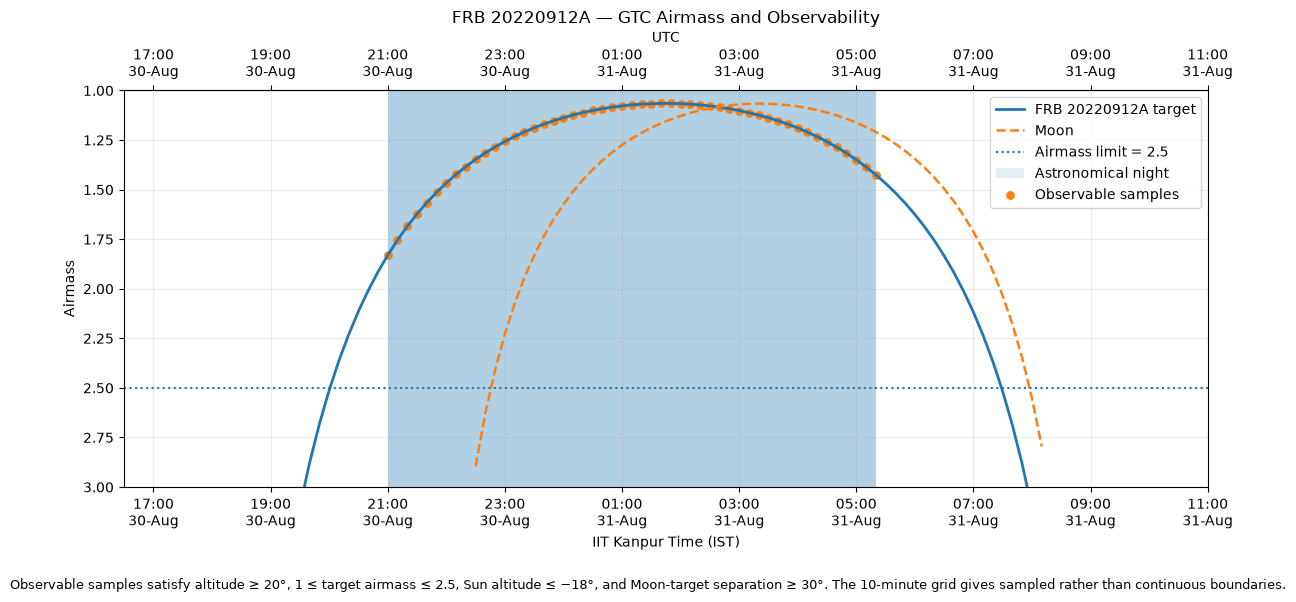


Figure saved to:
assignment_outputs/frb_20220912a_gtc_airmass.png


In [73]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from astropy import units as u
from zoneinfo import ZoneInfo

# ---------------------------------------------------------
# Part 1: Stitch consecutive observable samples
# ---------------------------------------------------------

def stitch_windows(times, visibility_state):
    times = np.asarray(times)
    visibility_state = np.asarray(visibility_state, dtype=bool)

    if times.ndim != 1 or visibility_state.ndim != 1:
        raise ValueError("times and visibility_state must be 1D arrays.")

    if len(times) != len(visibility_state):
        raise ValueError(
            "times and visibility_state must have the same length."
        )

    true_indices = np.where(visibility_state)[0]

    # No observable samples
    if len(true_indices) == 0:
        return []

    windows = []

    start = true_indices[0]
    previous = true_indices[0]

    for index in true_indices[1:]:
        if index != previous + 1:
            windows.append((start, previous))
            start = index

        previous = index

    # Add final window
    windows.append((start, previous))

    return windows


# Apply to preferred visibility from Q17
windows = stitch_windows(times, visibility_state)

print("Observable intervals")
print("====================")

if len(windows) == 0:
    print("No observable intervals found.")
else:
    for number, (start_index, end_index) in enumerate(windows, start=1):

        start_time_window = times[start_index]
        end_time_window = times[end_index]

        # Sample-centre duration
        duration = (
            end_time_window - start_time_window
        ).to_value(u.hour)

        best_index = start_index + np.nanargmin(
            target_airmass[start_index:end_index + 1]
        )

        best_airmass = target_airmass[best_index]

        midpoint_index = (
            start_index + end_index
        ) // 2

        midpoint_moon_label = moon_label[midpoint_index]

        start_ist = start_time_window.to_datetime(
            timezone=ZoneInfo("Asia/Kolkata")
        )
        end_ist = end_time_window.to_datetime(
            timezone=ZoneInfo("Asia/Kolkata")
        )

        print(f"\nInterval {number}")
        print("--------------------")

        print(
            "IIT Kanpur:",
            start_ist.strftime("%Y-%m-%d %H:%M:%S"),
            "to",
            end_ist.strftime("%Y-%m-%d %H:%M:%S"),
            "IST"
        )

        print(
            "UTC:",
            start_time_window.utc.strftime("%Y-%m-%d %H:%M:%S"),
            "to",
            end_time_window.utc.strftime("%Y-%m-%d %H:%M:%S"),
            "UTC"
        )

        print(
            "Sample-centre duration:",
            duration,
            "hours"
        )

        print(
            "Best target airmass:",
            best_airmass
        )

        print(
            "Midpoint Moon label:",
            midpoint_moon_label
        )


# ---------------------------------------------------------
# Part 2: Prepare airmass data for plotting
# ---------------------------------------------------------

# Target airmass
target_plot_airmass = np.array(target_airmass, dtype=float)

# Moon airmass
moon_plot_airmass = np.array(moon_airmass, dtype=float)


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

# Target airmass curve
ax.plot(
    times.to_datetime(),
    target_plot_airmass,
    linewidth=2,
    label="FRB 20220912A target"
)

# Moon airmass curve
ax.plot(
    times.to_datetime(),
    moon_plot_airmass,
    linestyle="--",
    linewidth=1.8,
    label="Moon"
)

# Airmass limit
ax.axhline(
    2.5,
    linestyle=":",
    linewidth=1.5,
    label="Airmass limit = 2.5"
)

# ---------------------------------------------------------
# Shade astronomical night
# ---------------------------------------------------------

night_mask = sun_altitude <= -18.0

ax.fill_between(
    times.to_datetime(),
    1,
    3,
    where=night_mask,
    alpha=0.12,
    label="Astronomical night"
)

# ---------------------------------------------------------
# Shade observable intervals
# ---------------------------------------------------------

for start_index, end_index in windows:
    ax.axvspan(
        times[start_index].to_datetime(),
        times[end_index].to_datetime(),
        alpha=0.25
    )

# Observable sample markers
observable_indices = np.where(visibility_state)[0]

if len(observable_indices) > 0:
    ax.scatter(
        times[observable_indices].to_datetime(),
        target_plot_airmass[observable_indices],
        marker="o",
        s=28,
        label="Observable samples"
    )

# ---------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------

ax.set_ylim(3, 1)

ax.set_ylabel("Airmass")
ax.set_xlabel("IIT Kanpur Time (IST)")

ax.xaxis.set_major_locator(
    mdates.HourLocator(interval=2)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M\n%d-%b")
)

ax.grid(True, alpha=0.25)

ax.set_title(
    "FRB 20220912A — GTC Airmass and Observability"
)

# ---------------------------------------------------------
# Aligned UTC axis above
# ---------------------------------------------------------

ax_utc = ax.secondary_xaxis("top")

ax_utc.xaxis.set_major_locator(
    mdates.HourLocator(interval=2)
)

ax_utc.xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M\n%d-%b")
)

ax_utc.set_xlabel("UTC")

# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------

ax.legend(
    loc="upper right"
)

# Caption
fig.text(
    0.5,
    0.01,
    "Observable samples satisfy altitude ≥ 20°, "
    "1 ≤ target airmass ≤ 2.5, Sun altitude ≤ −18°, "
    "and Moon-target separation ≥ 30°. "
    "The 10-minute grid gives sampled rather than continuous boundaries.",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

# Save required figure
output_path = (
    OUTPUT_DIR /
    "frb_20220912a_gtc_airmass.png"
)

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

### Interpretation

The calculated observing interval is determined by the samples for which all required visibility conditions are simultaneously satisfied. The target must have sufficient altitude, acceptable airmass, astronomical darkness, and adequate separation from the Moon.

The airmass plot shows how the target's atmospheric path length changes during the observation period. Lower airmass corresponds to a higher target altitude and therefore generally better observing conditions.

The main limitation of the 10-minute grid is that the exact beginning and end of an observable interval may occur between two sampled times. Therefore, the reported interval represents the sampled observation window rather than the exact continuous visibility boundaries.

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [74]:
import numpy as np
from astropy.time import Time
from astropy.coordinates import AltAz
from astropy import units as u
from zoneinfo import ZoneInfo

# ---------------------------------------------------------
# Q19: Full UTC day on 2026-09-01
# ---------------------------------------------------------

q19_start = Time(
    "2026-09-01T00:00:00",
    scale="utc"
)

q19_stop = Time(
    "2026-09-02T00:00:00",
    scale="utc"
)

# 10-minute sampling, endpoints included
q19_times = q19_start + np.arange(145) * 10 * u.min

# GTC AltAz frame
q19_altaz_frame = AltAz(
    obstime=q19_times,
    location=gtc_location,
    pressure=0 * u.hPa
)

# Target position at GTC
q19_target_altaz = frb_icrs.transform_to(
    q19_altaz_frame
)

q19_altitude = q19_target_altaz.alt.to_value(u.deg)

q19_airmass = np.asarray(
    q19_target_altaz.secz.to_value(
        u.dimensionless_unscaled
    ),
    dtype=float
)

# Sun altitude
with solar_system_ephemeris.set("builtin"):
    q19_sun = get_sun(q19_times)

q19_sun_altaz = q19_sun.transform_to(
    q19_altaz_frame
)

q19_sun_altitude = q19_sun_altaz.alt.to_value(u.deg)

# ---------------------------------------------------------
# Visibility conditions
# ---------------------------------------------------------

q19_night = (
    np.isfinite(q19_sun_altitude)
    & (q19_sun_altitude <= -18.0)
)

q19_altitude_ok = (
    np.isfinite(q19_altitude)
    & (q19_altitude > 0.0)
)

q19_airmass_ok = (
    np.isfinite(q19_airmass)
    & (q19_airmass <= 2.5)
)

# All three conditions must be satisfied
q19_visibility = (
    q19_night
    & q19_altitude_ok
    & q19_airmass_ok
)

# ---------------------------------------------------------
# Find contiguous visibility intervals
# ---------------------------------------------------------

q19_windows = []

visible_indices = np.where(q19_visibility)[0]

if len(visible_indices) > 0:

    window_start = visible_indices[0]
    previous = visible_indices[0]

    for index in visible_indices[1:]:

        if index != previous + 1:
            q19_windows.append(
                (window_start, previous)
            )
            window_start = index

        previous = index

    # Add final interval
    q19_windows.append(
        (window_start, previous)
    )

# ---------------------------------------------------------
# Print results
# ---------------------------------------------------------

print("Q19: GTC visibility of FRB 20220912A")
print("=" * 55)
print("Date: 2026-09-01")
print("Sampling: 10 minutes")
print("Conditions:")
print("  Astronomical night: Sun altitude <= -18 deg")
print("  Target altitude > 0 deg")
print("  Target airmass <= 2.5")

print("\nNumber of observable samples:",
      len(visible_indices))

print("Number of visibility intervals:",
      len(q19_windows))

# ---------------------------------------------------------
# Report each interval
# ---------------------------------------------------------

if len(q19_windows) == 0:

    print("\nNo visibility interval found.")

else:

    print("\nVisibility intervals")
    print("-" * 55)

    total_duration = 0.0

    for number, (start_index, end_index) in enumerate(
        q19_windows, start=1
    ):

        start = q19_times[start_index]
        end = q19_times[end_index]

        # Sample-centre duration
        duration = (
            end - start
        ).to_value(u.hour)

        total_duration += duration

        start_ist = start.to_datetime(
            timezone=ZoneInfo("Asia/Kolkata")
        )

        end_ist = end.to_datetime(
            timezone=ZoneInfo("Asia/Kolkata")
        )

        print(f"\nInterval {number}")
        print(
            "UTC:",
            start.utc.strftime("%Y-%m-%d %H:%M:%S"),
            "to",
            end.utc.strftime("%Y-%m-%d %H:%M:%S")
        )

        print(
            "IIT Kanpur:",
            start_ist.strftime("%Y-%m-%d %H:%M:%S IST"),
            "to",
            end_ist.strftime("%Y-%m-%d %H:%M:%S IST")
        )

        print(
            "Visible duration:",
            duration,
            "hours"
        )

    print("\nTotal visible duration:",
          total_duration,
          "hours")

Q19: GTC visibility of FRB 20220912A
Date: 2026-09-01
Sampling: 10 minutes
Conditions:
  Astronomical night: Sun altitude <= -18 deg
  Target altitude > 0 deg
  Target airmass <= 2.5

Number of observable samples: 52
Number of visibility intervals: 2

Visibility intervals
-------------------------------------------------------

Interval 1
UTC: 2026-09-01 00:00:00 to 2026-09-01 05:20:00
IIT Kanpur: 2026-09-01 05:30:00 IST to 2026-09-01 10:50:00 IST
Visible duration: 5.333333333333333 hours

Interval 2
UTC: 2026-09-01 21:00:00 to 2026-09-02 00:00:00
IIT Kanpur: 2026-09-02 02:30:00 IST to 2026-09-02 05:30:00 IST
Visible duration: 3.0 hours

Total visible duration: 8.333333333333332 hours


### Interpretation

FRB 20220912A is considered visible from GTC when all three conditions are satisfied simultaneously:

$$
h > 0^\circ
$$

$$
X \leq 2.5
$$

and

$$
h_{\mathrm{Sun}} \leq -18^\circ.
$$

The start and end times are determined from the 10-minute sampled grid. Therefore, the reported durations are sample-centre durations and the exact continuous visibility boundaries may occur between two sampled times.

Unlike Q16–Q18, the Moon constraint is not applied in Q19 because this question asks specifically for the geometric and airmass visibility of the repeating FRB across one full date.

## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [75]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from astropy.time import Time
from astropy.coordinates import SkyCoord, AltAz, get_sun
from astropy import units as u
from PIL import Image
from pathlib import Path

# ---------------------------------------------------------
# Q20: One-year all-sky GTC visibility animation
# ---------------------------------------------------------

# Weekly dates: 2026-08-30 to 2027-08-29
start_date = Time("2026-08-30T00:00:00", scale="utc")
dates = start_date + np.arange(53) * 7 * u.day

# Make sure the final date is 2027-08-29
dates = dates[dates <= Time("2027-08-29T23:59:59", scale="utc")]

print("Number of weekly dates:", len(dates))
print("First date:", dates[0].utc.isot)
print("Last date:", dates[-1].utc.isot)

# ---------------------------------------------------------
# HEALPix resolution
# ---------------------------------------------------------

# Moderate resolution for practical computation
nside = 32
npix = hp.nside2npix(nside)

print("HEALPix NSIDE:", nside)
print("Number of sky pixels:", npix)

# ---------------------------------------------------------
# HEALPix pixel coordinates
# ---------------------------------------------------------

theta, phi = hp.pix2ang(
    nside,
    np.arange(npix)
)

# theta = colatitude
# phi = right ascension
ra_deg = np.degrees(phi)
dec_deg = 90.0 - np.degrees(theta)

sky_coordinates = SkyCoord(
    ra=ra_deg * u.deg,
    dec=dec_deg * u.deg,
    frame="icrs"
)

# ---------------------------------------------------------
# Output directory
# ---------------------------------------------------------

frame_dir = OUTPUT_DIR / "q20_frames"
frame_dir.mkdir(
    parents=True,
    exist_ok=True
)

frame_paths = []

# ---------------------------------------------------------
# Calculate one visibility map for each week
# ---------------------------------------------------------

for i, date in enumerate(dates):

    # Sample the date at several times through the UTC day.
    # A 1-hour grid is sufficient for this bonus animation.
    day_times = date + np.arange(24) * u.hour

    visible_map = np.zeros(
        npix,
        dtype=bool
    )

    for current_time in day_times:

        # GTC AltAz frame
        altaz_frame = AltAz(
            obstime=current_time,
            location=gtc_location,
            pressure=0 * u.hPa
        )

        # Target sky coordinates -> GTC AltAz
        sky_altaz = sky_coordinates.transform_to(
            altaz_frame
        )

        altitude = sky_altaz.alt.to_value(u.deg)

        airmass = np.asarray(
            sky_altaz.secz.to_value(
                u.dimensionless_unscaled
            ),
            dtype=float
        )

        # Sun altitude
        sun = get_sun(current_time)

        sun_altaz = sun.transform_to(
            altaz_frame
        )

        sun_altitude = sun_altaz.alt.to_value(
            u.deg
        )

        # -------------------------------------------------
        # GTC visibility conditions
        # -------------------------------------------------

        night_ok = (
            np.isfinite(sun_altitude)
            & (sun_altitude <= -18.0)
        )

        altitude_ok = (
            np.isfinite(altitude)
            & (altitude > 0.0)
        )

        airmass_ok = (
            np.isfinite(airmass)
            & (airmass >= 1.0)
            & (airmass <= 2.5)
        )

        current_visibility = (
            night_ok
            & altitude_ok
            & airmass_ok
        )

        # If visible at any sampled time during the night,
        # mark that sky position as observable for the day.
        visible_map |= current_visibility

    # -----------------------------------------------------
    # Make HEALPix map
    # -----------------------------------------------------

    map_values = np.where(
        visible_map,
        1.0,
        0.0
    )

    # Create figure
    fig = plt.figure(
        figsize=(10, 6)
    )

    hp.mollview(
        map_values,
        fig=fig.number,
        title=(
            "GTC Observable Sky\n"
            + date.utc.strftime("%Y-%m-%d")
        ),
        coord=["C"],
        min=0,
        max=1,
        cbar=False,
        notext=False
    )

    # Save frame
    frame_path = (
        frame_dir
        / f"gtc_visibility_{i:03d}.png"
    )

    plt.savefig(
        frame_path,
        dpi=120,
        bbox_inches="tight"
    )

    plt.close(fig)

    frame_paths.append(frame_path)

    print(
        f"Frame {i + 1}/{len(dates)} saved:",
        date.utc.strftime("%Y-%m-%d")
    )

# ---------------------------------------------------------
# Combine PNG frames into GIF
# ---------------------------------------------------------

images = [
    Image.open(path).convert("P", palette=Image.ADAPTIVE)
    for path in frame_paths
]

gif_path = (
    OUTPUT_DIR
    / "frb_20220912a_gtc_visibility_one_year.gif"
)

images[0].save(
    gif_path,
    save_all=True,
    append_images=images[1:],
    duration=500,
    loop=0
)

print("\nAnimation completed.")
print("GIF saved to:")
print(gif_path)

Number of weekly dates: 53
First date: 2026-08-30T00:00:00.000
Last date: 2027-08-29T00:00:00.000
HEALPix NSIDE: 32
Number of sky pixels: 12288
Frame 1/53 saved: 2026-08-30
Frame 2/53 saved: 2026-09-06
Frame 3/53 saved: 2026-09-13
Frame 4/53 saved: 2026-09-20
Frame 5/53 saved: 2026-09-27
Frame 6/53 saved: 2026-10-04
Frame 7/53 saved: 2026-10-11
Frame 8/53 saved: 2026-10-18
Frame 9/53 saved: 2026-10-25
Frame 10/53 saved: 2026-11-01
Frame 11/53 saved: 2026-11-08
Frame 12/53 saved: 2026-11-15
Frame 13/53 saved: 2026-11-22
Frame 14/53 saved: 2026-11-29
Frame 15/53 saved: 2026-12-06
Frame 16/53 saved: 2026-12-13
Frame 17/53 saved: 2026-12-20
Frame 18/53 saved: 2026-12-27
Frame 19/53 saved: 2027-01-03
Frame 20/53 saved: 2027-01-10
Frame 21/53 saved: 2027-01-17
Frame 22/53 saved: 2027-01-24
Frame 23/53 saved: 2027-01-31
Frame 24/53 saved: 2027-02-07
Frame 25/53 saved: 2027-02-14
Frame 26/53 saved: 2027-02-21
Frame 27/53 saved: 2027-02-28
Frame 28/53 saved: 2027-03-07
Frame 29/53 saved: 2027-0

### Interpretation

The animation shows how the observable sky from GTC changes over one year.

The observable region changes with date because the Earth's rotation determines which right ascensions are above the GTC horizon during astronomical night, while the Earth's orbit around the Sun changes the local time of astronomical darkness throughout the year.

The airmass requirement also removes sky positions that are too close to the horizon. Therefore, the visible region is determined by the combined effects of the GTC altitude limit, airmass limit, and astronomical-night condition.

A moderate HEALPix resolution is used so that the one-year calculation and GIF generation remain computationally practical.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
